In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Shape :", df.shape)

df.info()

Shape : (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


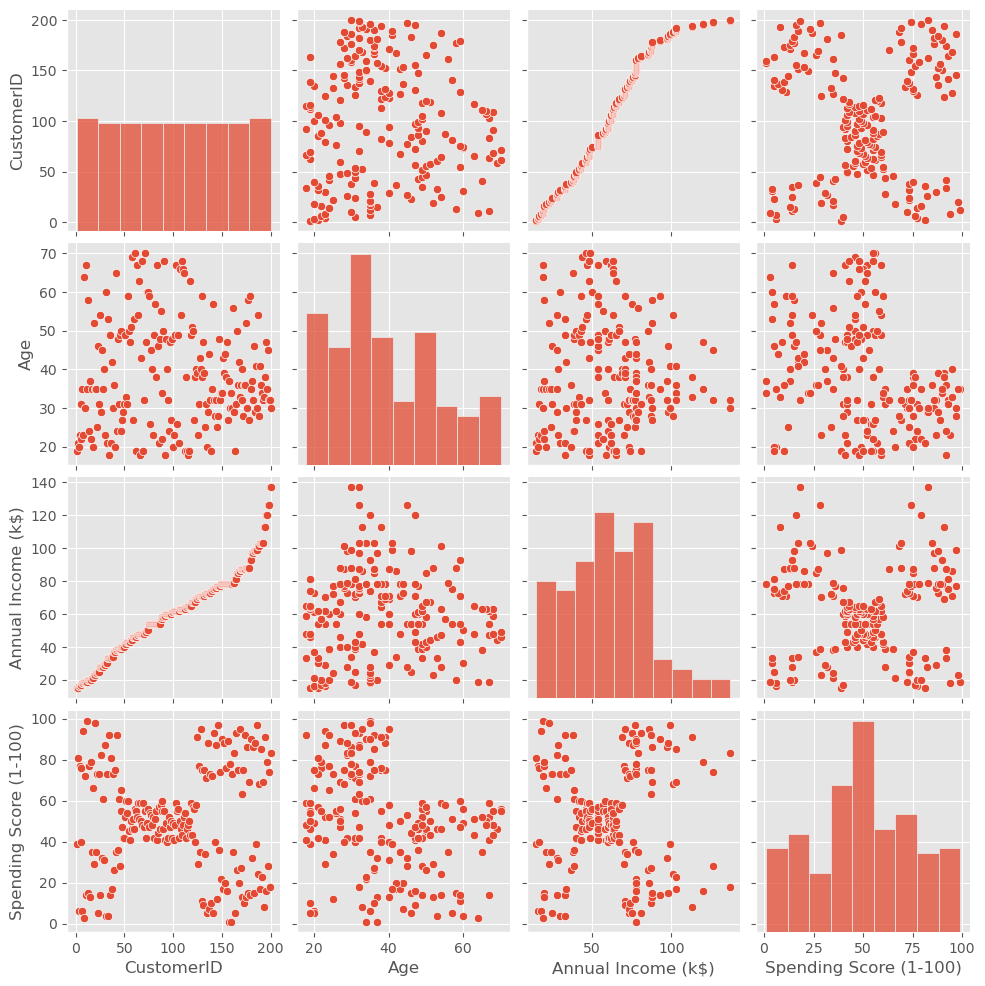

In [6]:
sns.pairplot(df)

plt.show()

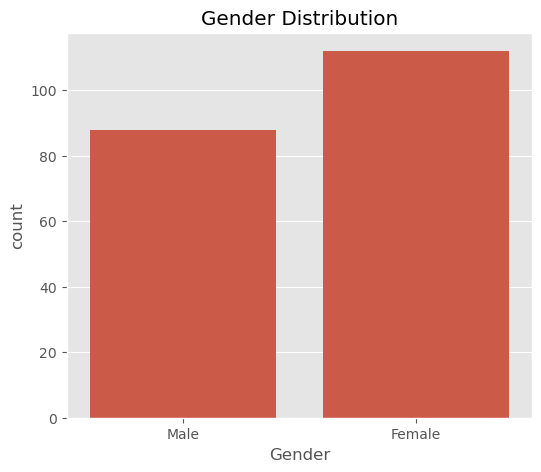

In [7]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")

plt.show()

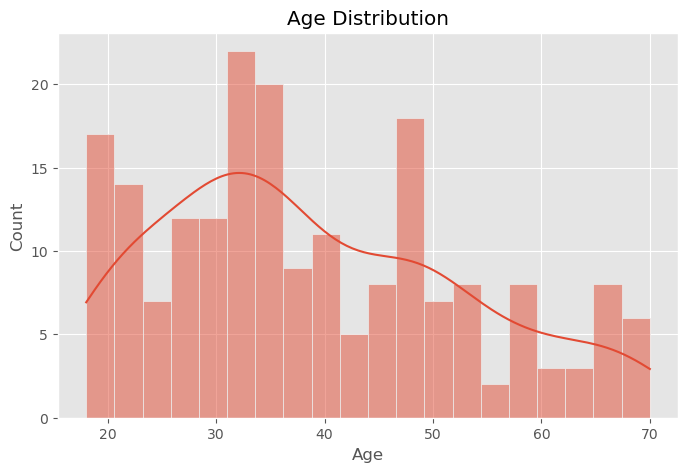

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

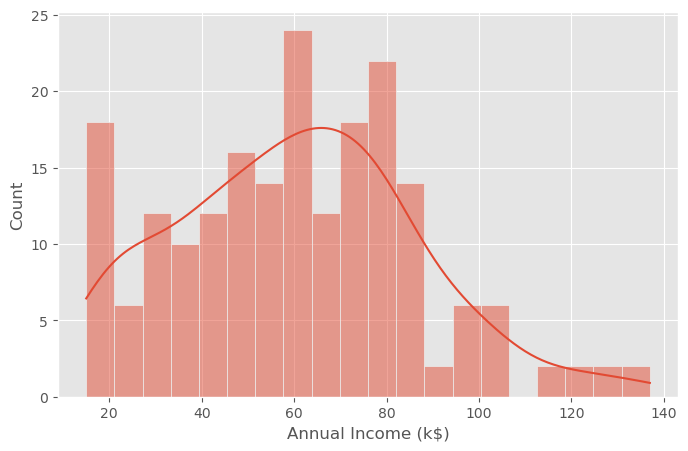

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Annual Income (k$)"],
    bins=20,
    kde=True
)

plt.show()

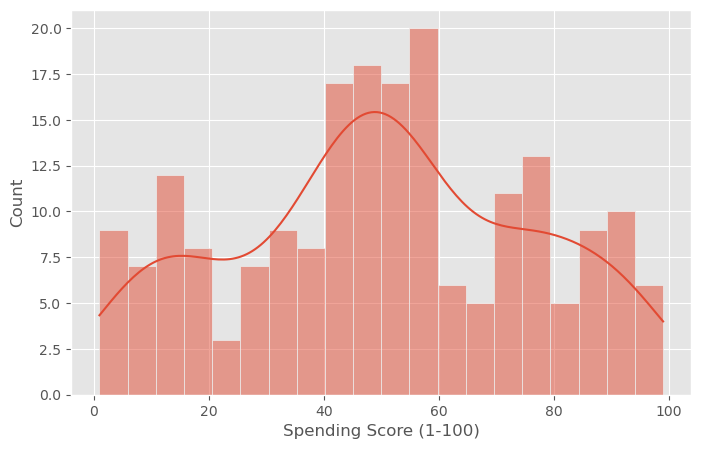

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Spending Score (1-100)"],
    bins=20,
    kde=True
)

plt.show()

In [11]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

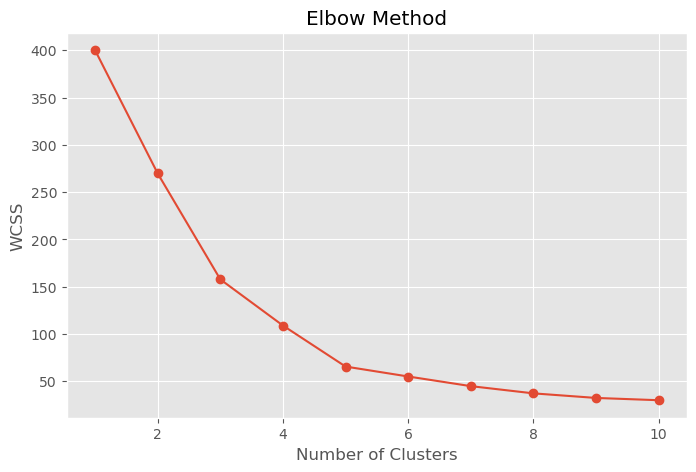

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

C:\Users\Manav\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [17]:
df["Cluster"].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [18]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(centers)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [19]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score :", score)

Silhouette Score : 0.5546571631111091


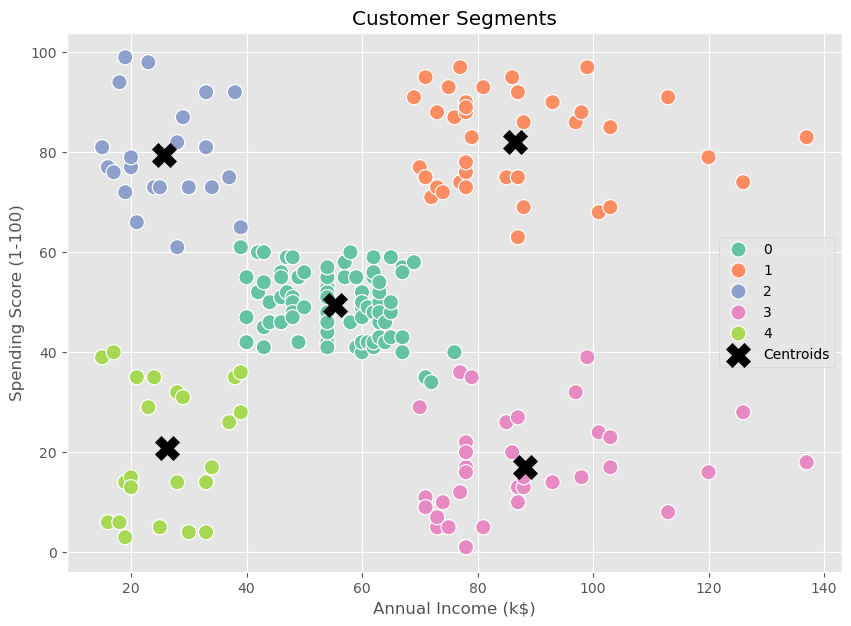

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=120
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color="black",
    marker="X",
    s=300,
    label="Centroids"
)

plt.legend()

plt.title("Customer Segments")

plt.show()

In [21]:
cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [22]:
cluster_names = {
    0:"Premium Customers",
    1:"Careful Spenders",
    2:"Average Customers",
    3:"High Income Low Spending",
    4:"Budget Customers"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Budget Customers
1,2,Male,21,15,81,2,Average Customers
2,3,Female,20,16,6,4,Budget Customers
3,4,Female,23,16,77,2,Average Customers
4,5,Female,31,17,40,4,Budget Customers


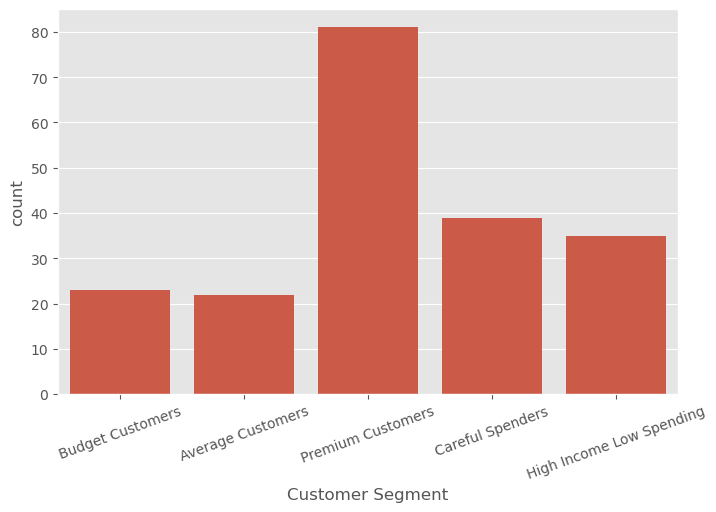

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer Segment"
)

plt.xticks(rotation=20)

plt.show()

In [24]:
print("""

Business Recommendations

Premium Customers
→ Loyalty Rewards

Careful Spenders
→ Discount Coupons

Average Customers
→ Membership Plans

High Income Low Spending
→ Personalized Marketing

Budget Customers
→ Seasonal Offers

""")



Business Recommendations

Premium Customers
→ Loyalty Rewards

Careful Spenders
→ Discount Coupons

Average Customers
→ Membership Plans

High Income Low Spending
→ Personalized Marketing

Budget Customers
→ Seasonal Offers




In [25]:
df.to_csv(
    "Segmented_Customers.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [26]:
print("""

Project Completed Successfully

✔ Customer Segmentation Performed

✔ Optimal Clusters Identified

✔ Customer Profiles Created

✔ Business Recommendations Generated

""")



Project Completed Successfully

✔ Customer Segmentation Performed

✔ Optimal Clusters Identified

✔ Customer Profiles Created

✔ Business Recommendations Generated


